# Upload data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
pas = pd.read_csv("/content/uc3m-personal-pas-2023-anonimizado_0.xlsx - Sheet1.csv")

pas.head()

,IMPORTANTE,cod_universidad,des_universidad,anio,cod_pais_nacionalidad,des_pais_nacionalidad,lat_pais_nacionalidad,lon_pais_nacionalidad,cod_continente_nacionalidad,des_continente_nacionalidad,...,cod_titulacion_exigida,des_titulacion_exigida,cod_dedicacion,des_dedicacion,num_horas_semanales_tiempo_parcial,cod_situacion_administrativa,des_situacion_administrativa,ind_cargo_remunerado,ind_imparte_docencia,num_trienios
0,LOS DATOS DE ESTA FILA NO CORRESPONDEN A UN SÓ...,36,Universidad Carlos III de Madrid,2023,724,España,40.463667,-3.74922,150,Europa,...,8.0,Personal Funcionario\Personal eventual,1,Dedicación a Tiempo Completo,NaN,1,Servicio Activo,N,N,4
1,LOS DATOS DE ESTA FILA NO CORRESPONDEN A UN SÓ...,36,Universidad Carlos III de Madrid,2023,724,España,40.463667,-3.74922,150,Europa,...,8.0,Personal Funcionario\Personal eventual,1,Dedicación a Tiempo Completo,NaN,1,Servicio Activo,N,N,11
2,LOS DATOS DE ESTA FILA NO CORRESPONDEN A UN SÓ...,36,Universidad Carlos III de Madrid,2023,724,España,40.463667,-3.74922,150,Europa,...,8.0,Personal Funcionario\Personal eventual,1,Dedicación a Tiempo Completo,NaN,1,Servicio Activo,N,N,5
3,LOS DATOS DE ESTA FILA NO CORRESPONDEN A UN SÓ...,36,Universidad Carlos III de Madrid,2023,724,España,40.463667,-3.74922,150,Europa,...,8.0,Personal Funcionario\Personal eventual,8,Se desconoce por estar en otra institución (no...,NaN,1,Servicio Activo,N,N,4
4,LOS DATOS DE ESTA FILA NO CORRESPONDEN A UN SÓ...,36,Universidad Carlos III de Madrid,2023,724,España,40.463667,-3.74922,150,Europa,...,8.0,Personal Funcionario\Personal eventual,1,Dedicación a Tiempo Completo,NaN,1,Servicio Activo,N,N,4


# Inspect structure

In [4]:
print("Shape:", pas.shape)

print("\nColumns:")
print(pas.columns)

print("\nMissing values:")
print(pas.isnull().sum())

Shape: (760, 45)

Columns:
Index(['IMPORTANTE', 'cod_universidad', 'des_universidad', 'anio',
       'cod_pais_nacionalidad', 'des_pais_nacionalidad',
       'lat_pais_nacionalidad', 'lon_pais_nacionalidad',
       'cod_continente_nacionalidad', 'des_continente_nacionalidad',
       'cod_agregacion_paises_nacionalidad',
       'des_agregacion_paises_nacionalidad', 'cod_comunidad_residencia',
       'des_comunidad_residencia', 'cod_provincia_residencia',
       'des_provincia_residencia', 'cod_municipio_residencia',
       'des_municipio_residencia', 'lat_municipio_residencia',
       'lon_municipio_residencia', 'cod_genero', 'des_genero',
       'anio_nacimiento', 'anio_incorporacion', 'ind_otra_unidad',
       'cod_otra_unidad', 'des_otra_unidad', 'cod_servicio_prestado',
       'des_servicio_prestado', 'cod_tipo_personal', 'des_tipo_personal',
       'cod_cuerpo_escala_PAS', 'des_cuerpo_escala_PAS', 'cod_tipo_contrato',
       'des_tipo_contrato', 'cod_titulacion_exigida', 'des_titul

In [5]:
pas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 760 entries, 0 to 759
Data columns (total 45 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   IMPORTANTE                          760 non-null    object 
 1   cod_universidad                     760 non-null    int64  
 2   des_universidad                     760 non-null    object 
 3   anio                                760 non-null    int64  
 4   cod_pais_nacionalidad               760 non-null    int64  
 5   des_pais_nacionalidad               760 non-null    object 
 6   lat_pais_nacionalidad               760 non-null    float64
 7   lon_pais_nacionalidad               760 non-null    float64
 8   cod_continente_nacionalidad         760 non-null    int64  
 9   des_continente_nacionalidad         760 non-null    object 
 10  cod_agregacion_paises_nacionalidad  760 non-null    int64  
 11  des_agregacion_paises_nacionalidad  760 non-n

# Relevant columns

In [25]:
cols_keep = [
    "cod_universidad",
    "des_universidad",
    "anio",
    "des_pais_nacionalidad",
    "des_genero",
    "anio_incorporacion",
    "des_servicio_prestado",
    "des_tipo_personal",
    "des_tipo_contrato",
    "des_dedicacion",
    "des_situacion_administrativa",
    "ind_imparte_docencia",
    "num_trienios"
]

pas_clean = pas[cols_keep].copy()

pas_clean.head()

,cod_universidad,des_universidad,anio,des_pais_nacionalidad,des_genero,anio_incorporacion,des_servicio_prestado,des_tipo_personal,des_tipo_contrato,des_dedicacion,des_situacion_administrativa,ind_imparte_docencia,num_trienios
0,36,Universidad Carlos III de Madrid,2023,España,Mujer,1999,Otros,Funcionario de carrera,Personal Funcionario\Personal eventual,Dedicación a Tiempo Completo,Servicio Activo,N,4
1,36,Universidad Carlos III de Madrid,2023,España,Mujer,2001,Otros,Funcionario de carrera,Personal Funcionario\Personal eventual,Dedicación a Tiempo Completo,Servicio Activo,N,11
2,36,Universidad Carlos III de Madrid,2023,España,Mujer,2022,Otros,Funcionario de carrera,Personal Funcionario\Personal eventual,Dedicación a Tiempo Completo,Servicio Activo,N,5
3,36,Universidad Carlos III de Madrid,2023,España,Mujer,1991,Otros,Funcionario de carrera,Personal Funcionario\Personal eventual,Se desconoce por estar en otra institución (no...,Servicio Activo,N,4
4,36,Universidad Carlos III de Madrid,2023,España,Mujer,1991,Otros,Funcionario de carrera,Personal Funcionario\Personal eventual,Dedicación a Tiempo Completo,Servicio Activo,N,4


# Remove rows with missing key values

In [9]:
pas_clean = pas_clean.dropna(
    subset=[
        "des_genero",
    ]
)

pas_clean.shape

(755, 11)

# Creating useful variables


Years working at UC3M

In [12]:
pas_clean["antiguedad"] = 2023 - pas_clean["anio_incorporacion"]

# Basic statistics

Years working

In [14]:
pas_clean["antiguedad"].describe()

,antiguedad
count,760.00000
mean,16.47500
std,9.75156
min,0.00000
25%,8.00000
50%,17.00000
75%,24.00000
max,34.00000


Trienios

In [15]:
pas_clean["num_trienios"].describe()

,num_trienios
count,760.000000
mean,5.785526
std,3.768331
min,0.000000
25%,2.000000
50%,6.000000
75%,8.000000
max,15.000000


# Categorical analysis

Gender distribution

In [16]:
pas_clean["des_genero"].value_counts()

,count
des_genero,
Mujer,495
Hombre,260


Contract type

In [17]:
pas_clean["des_tipo_contrato"].value_counts()

,count
des_tipo_contrato,
Personal Funcionario\Personal eventual,577
Contrato Indefinido o Fijo,164
Contrato de Duración Determinada,14


Dedication

In [18]:
pas_clean["des_dedicacion"].value_counts()

,count
des_dedicacion,
Dedicación a Tiempo Completo,714
Se desconoce por estar en otra institución (no aplica),32
Dedicación a Tiempo Parcial,14


# Visualizations

Gender distribution

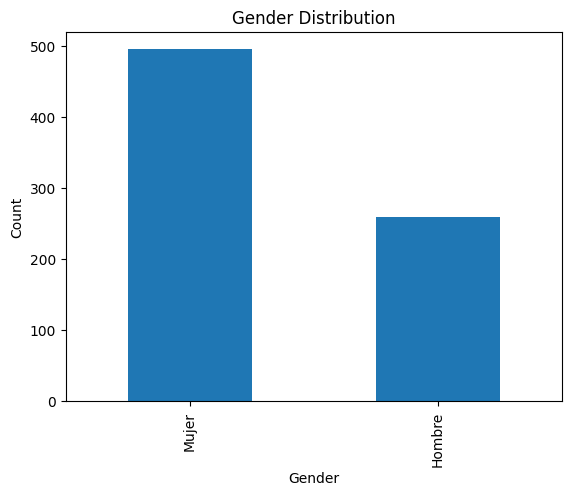

In [19]:
pas_clean["des_genero"].value_counts().plot(kind="bar")

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

Contract types

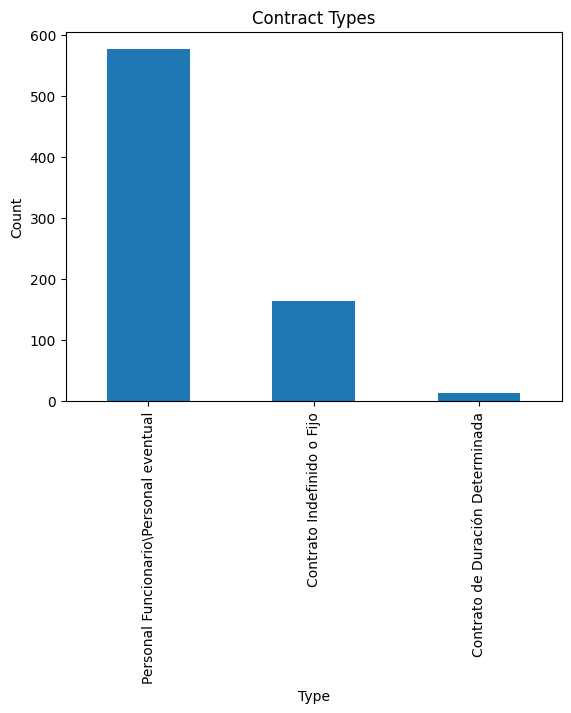

In [21]:
pas_clean["des_tipo_contrato"].value_counts().plot(kind="bar")

plt.title("Contract Types")
plt.xlabel("Type")
plt.ylabel("Count")
plt.show()

# Average seniority by contract type

In [23]:
pas_clean.groupby("des_tipo_contrato")["antiguedad"].mean()

,antiguedad
des_tipo_contrato,
Contrato Indefinido o Fijo,18.500000
Contrato de Duración Determinada,16.857143
Personal Funcionario\Personal eventual,15.909879


# Total staff by nationality

In [26]:
pas_clean["des_pais_nacionalidad"].value_counts().head(10)

,count
des_pais_nacionalidad,
España,758
Italia,2


# Create an ID column

In [27]:
pas_clean = pas_clean.reset_index(drop=True)

pas_clean.insert(0, "staff_id", pas_clean.index + 1)

# Export cleaned dataset

In [28]:
pas_clean.to_csv("pas_uc3m_clean.csv", index=False)